In [8]:
from google.colab import drive
drive.mount('/content/drive')
caminho_dados='/content/drive/MyDrive/projeto despesas publicas/despesaspororgao.csv'



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
df_projeto = pd.read_csv(caminho_dados, sep=';', encoding='utf-8')
df_projeto.columns = df_projeto.columns.str.lower()







df_projeto['data'] = pd.to_datetime(df_projeto['mês ano'])

df_projeto['mes'] = df_projeto['data'].dt.to_period('M')


colunas_valor = [
    'valor empenhado',
    'valor liquidado',
    'valor pago',
    'valor restos a pagar pagos'
]

for col in colunas_valor:
    df_projeto[col] = (
        df_projeto[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )

    df_projeto[col] = pd.to_numeric(df_projeto[col], errors='coerce')

    import matplotlib.pyplot as plt




/tmp/ipykernel_88750/592042749.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_projeto['data'] = pd.to_datetime(df_projeto['mês ano'])


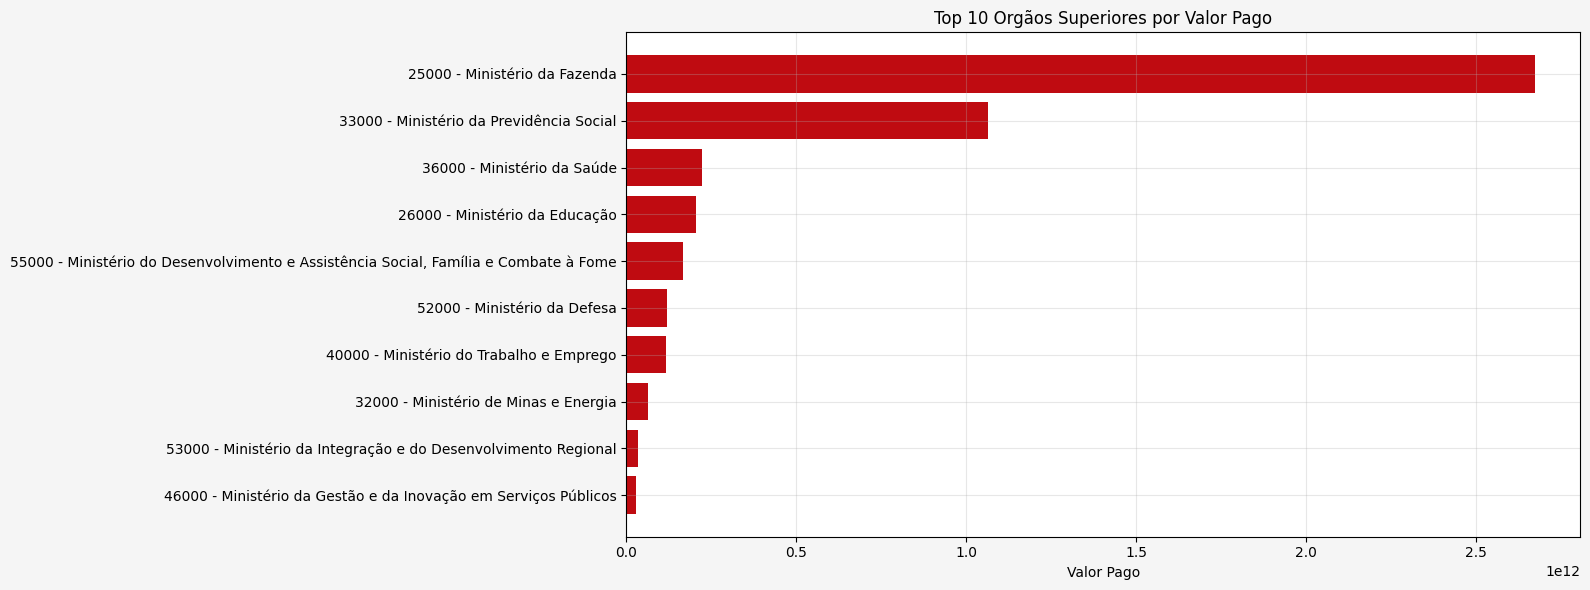

In [10]:

ranking_orgao=df_projeto.groupby('órgão superior')['valor pago'].sum().sort_values(ascending=False).reset_index()

top10=ranking_orgao.head(10)
top10

plt.figure(figsize=(16,6), facecolor='#f5f5f5')
plt.barh(top10['órgão superior'],top10['valor pago'], color='#bf0b11')
plt.gca().invert_yaxis()
plt.title('Top 10 Orgãos Superiores por Valor Pago')
plt.xlabel('Valor Pago')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()





In [11]:
gasto_ano= df_projeto.groupby(['mes','órgão superior'])['valor pago'].sum().reset_index()
gasto_ano
gasto_ano_detalhado  = gasto_ano.pivot(index='mes', columns='órgão superior', values='valor pago')
gasto_ano_detalhado

órgão superior,20000 - Presidência da República,22000 - Ministério da Agricultura e Pecuária,"24000 - Ministério da Ciência, Tecnologia e Inovação",25000 - Ministério da Fazenda,25201 - Banco Central do Brasil - Orçamento Fiscal e Seguridade Social,26000 - Ministério da Educação,"28000 - Ministério do Desenvolvimento, Indústria, Comércio e Serviços",30000 - Ministério da Justiça e Segurança Pública,32000 - Ministério de Minas e Energia,33000 - Ministério da Previdência Social,35000 - Ministério das Relações Exteriores,36000 - Ministério da Saúde,37000 - Controladoria-Geral da União,39000 - Ministério dos Transportes,40000 - Ministério do Trabalho e Emprego,41000 - Ministério das Comunicações,42000 - Ministério da Cultura,44000 - Ministério do Meio Ambiente e Mudança do Clima,46000 - Ministério da Gestão e da Inovação em Serviços Públicos,47000 - Ministério do Planejamento e Orçamento,49000 - Ministério do Desenvolvimento Agrário e Agricultura Familiar,51000 - Ministério do Esporte,52000 - Ministério da Defesa,53000 - Ministério da Integração e do Desenvolvimento Regional,54000 - Ministério do Turismo,"55000 - Ministério do Desenvolvimento e Assistência Social, Família e Combate à Fome",56000 - Ministério das Cidades,58000 - Ministério da Pesca e Aquicultura,63000 - Advocacia-Geral da União,65000 - Ministério das Mulheres,67000 - Ministério da Igualdade Racial,68000 - Ministério de Portos e Aeroportos,"69000 - Ministério do Empreendedorismo, da Microempresa e da Empresa de Pequeno Porte",81000 - Ministério dos Direitos Humanos e Cidadania,84000 - Ministério dos Povos Indígenas
mes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01,20639489.47,10877710.45,164892228.71,590718033334.20,18565821.15,3483725673.68,3352370.99,63927904.56,276475745.25,21380044064.78,281658079.76,9362983266.57,16612671.14,8891115.15,4754560765.30,10034119.88,4992640.00,11408686.03,161012729.70,107142831.74,28720830.11,1105547.04,1632829080.30,1414317187.68,445524.37,13734226987.34,30998154.46,292022.91,48991951.05,13175.99,145711.00,3006900.39,49661.25,726007.34,9175835.56
2025-02,150896258.27,639199037.54,483078866.46,103569262408.56,311665054.70,13658819355.31,96157767.91,1229257598.46,4974376297.30,85774528213.31,381977709.98,13645918724.01,70594348.80,348538874.82,11030987521.23,112457567.12,62832008.52,207034496.07,2115185717.96,363000877.32,218337893.16,4331483.03,8192692650.28,3348481026.44,5745809.18,14549826447.03,132623734.10,4231044.35,324026853.94,1628356.40,1537309.16,53928904.39,1462163.35,5324107.89,47494578.86
2025-03,183382912.42,636811187.21,382319658.22,271607202260.62,306110405.32,14819909010.95,118043155.16,1283425670.97,4995547959.18,86756499974.84,387845826.11,13508282669.54,105729670.81,523349597.34,10214199620.15,80882438.22,87494118.16,229711876.49,2189215388.81,391634220.63,236350143.89,4651984.24,8264623502.30,2078060083.52,7543763.59,13972861146.44,141418348.43,6006571.55,352935287.23,1439652.19,1527823.70,57736276.69,1568884.42,8475944.14,51242358.61
2025-04,165489202.06,734170379.94,971153665.98,252348370154.85,343960559.03,16157257724.08,115092799.46,1362505835.44,4572235520.81,96073915529.07,410852580.72,16300346665.40,105884585.39,1282652874.18,12197928500.70,84579245.00,97331841.54,262961679.34,2240098492.65,787836440.92,234044677.71,20521612.26,9708523962.34,2527883007.72,9640070.12,14681456387.56,2444914573.19,6287280.35,354405104.95,1727441.63,1470141.23,267858841.84,1585592.87,12970009.47,55133195.27
2025-05,433106425.00,745518625.21,880639686.55,284148278691.11,536201245.24,18199123929.12,161835582.47,1347490934.14,9196087433.36,122929045220.29,455463878.56,17153895133.24,135634809.28,874715668.04,12081384792.41,114263437.24,313160259.12,10737429019.01,2480200721.81,549187634.93,663510638.67,37362250.75,9467856341.40,3075936653.52,25853869.10,13982286851.42,799707065.21,7496682.60,376835253.41,2360570.93,2108150.51,203531257.96,2546399.60,17728965.67,60961592.53
2025-06,212245659.45,714010949.37,5229776869.49,53104482411.

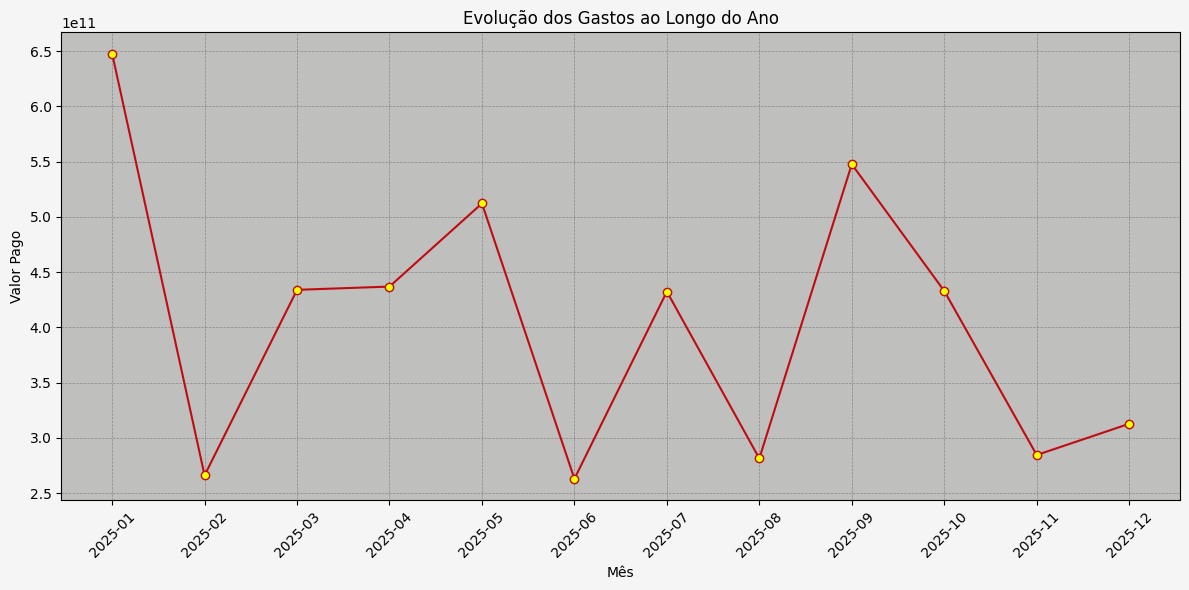

In [12]:


gasto_mensal = gasto_ano.groupby('mes')['valor pago'].sum().reset_index()
gasto_mensal= gasto_mensal.sort_values('mes')

plt.figure(figsize=(12,6), facecolor='#f5f5f5')

plt.plot(gasto_mensal['mes'].astype(str), gasto_mensal['valor pago'], marker='o', linestyle='-', color='#bf0b11', markerfacecolor='yellow',)


plt.title('Evolução dos Gastos ao Longo do Ano')
plt.xlabel('Mês')
plt.ylabel('Valor Pago')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.grid(color='#0f070f', linestyle='--', linewidth=0.5)
plt.gca().set_facecolor('#bfbfbd')


plt.tight_layout()
plt.show()




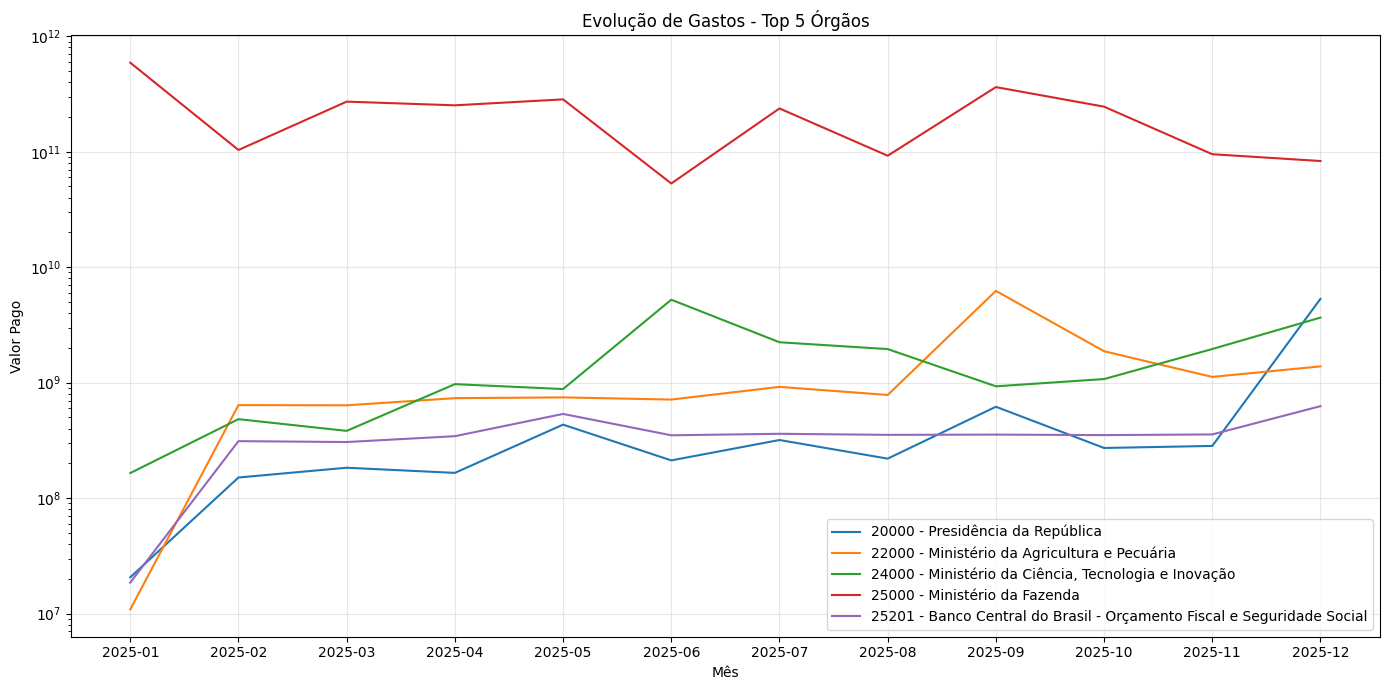

In [13]:
gasto_ano = df_projeto.groupby(['mes','órgão superior'])['valor pago'].sum().reset_index()


df_pivot = gasto_ano.pivot(index='mes', columns='órgão superior', values='valor pago')

top5 = gasto_ano.head(5)['órgão superior']

df_pivot_top5 = df_pivot[top5]

df_pivot_top5.index = df_pivot_top5.index.astype(str)

plt.figure(figsize=(14,7))

for coluna in df_pivot_top5.columns:
    plt.plot(df_pivot_top5.index, df_pivot_top5[coluna], label=coluna)

plt.legend()

plt.title('Evolução de Gastos - Top 5 Órgãos')
plt.xlabel('Mês')
plt.ylabel('Valor Pago')
plt.yscale('log')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()






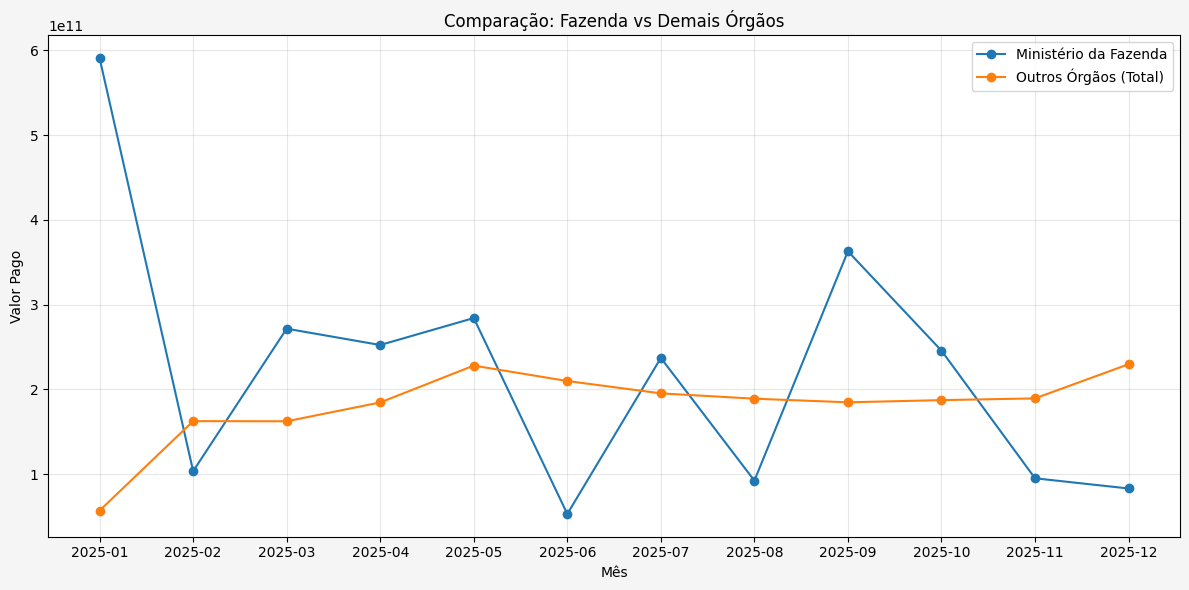

In [14]:
fazenda= df_pivot['25000 - Ministério da Fazenda']
outros_total = df_pivot.drop(columns=['25000 - Ministério da Fazenda']).sum(axis=1)



plt.figure(figsize=(12,6),facecolor='#f5f5f5')

plt.plot(df_pivot.index.astype(str), fazenda, label='Ministério da Fazenda', marker='o')

plt.plot(df_pivot.index.astype(str), outros_total, label='Outros Órgãos (Total)', marker='o')

plt.legend()

plt.title('Comparação: Fazenda vs Demais Órgãos')
plt.xlabel('Mês')
plt.ylabel('Valor Pago')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()